# Introduction

Website data analysis plays a crucial role in understanding user behavior, traffic patterns, and engagement levels. By analyzing website metrics such as sessions, traffic sources, engagement rate, and user activity over time, organizations can gain valuable insights into the effectiveness of their digital presence and marketing strategies.

In this project, website traffic data was analyzed using Python data analysis and visualization libraries. Various charts and graphs were created to explore traffic distribution, user engagement, channel performance, and hourly activity patterns. The objective of this analysis is to identify key trends, understand user interactions, and derive actionable insights that can help improve website performance and decision-making.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('wepsitedataset.csv')

# Clean the data

In [ ]:
df.columns=df.iloc[0]
df=df.drop(index=0,axis=0).reset_index(drop=True)



In [ ]:
df.columns=['channel group','datetime','users','sessions','engaged sessions','avg engagement per session','engaged session per user','event per session','Engagement rate','Event count']
df.head()

,channel group,datetime,users,sessions,engaged sessions,avg engagement per session,engaged session per user,event per session,Engagement rate,Event count
0,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
1,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
2,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
3,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
4,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001


In [ ]:
numeric=df.columns.drop(['channel group','datetime'])
df[numeric]=df[numeric].apply(pd.to_numeric,errors='coerce')


In [ ]:
df['datetime']=pd.to_datetime(df['datetime'],format='%Y%m%d%H',errors='coerce')
df['hours']=df['datetime'].dt.hour

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   channel group               3182 non-null   object        
 1   datetime                    3182 non-null   datetime64[ns]
 2   users                       3182 non-null   int64         
 3   sessions                    3182 non-null   int64         
 4   engaged sessions            3182 non-null   int64         
 5   avg engagement per session  3182 non-null   float64       
 6   engaged session per user    3182 non-null   float64       
 7   event per session           3182 non-null   float64       
 8   Engagement rate             3182 non-null   float64       
 9   Event count                 3182 non-null   int64         
 10  hours                       3182 non-null   int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(4), ob

In [ ]:
group=df.groupby("hours")[["users","sessions"]].sum().reset_index()
print(group)


    hours  users  sessions
0       0   5864      8148
1       1   4011      5228
2       2   3167      3999
3       3   2531      3199
4       4   2234      2786
5       5   2093      2598
6       6   2551      3161
7       7   3176      3946
8       8   3855      4781
9       9   5043      6221
10     10   6365      7791
11     11   7228      8629
12     12   7077      8398
13     13   6640      7905
14     14   7142      8399
15     15   7178      8647
16     16   6899      8467
17     17   6745      8165
18     18   7159      8593
19     19   7543      9129
20     20   7517      8996
21     21   7568      9056
22     22   7280      8777
23     23   6574      7876


# Trend of session and user over the time

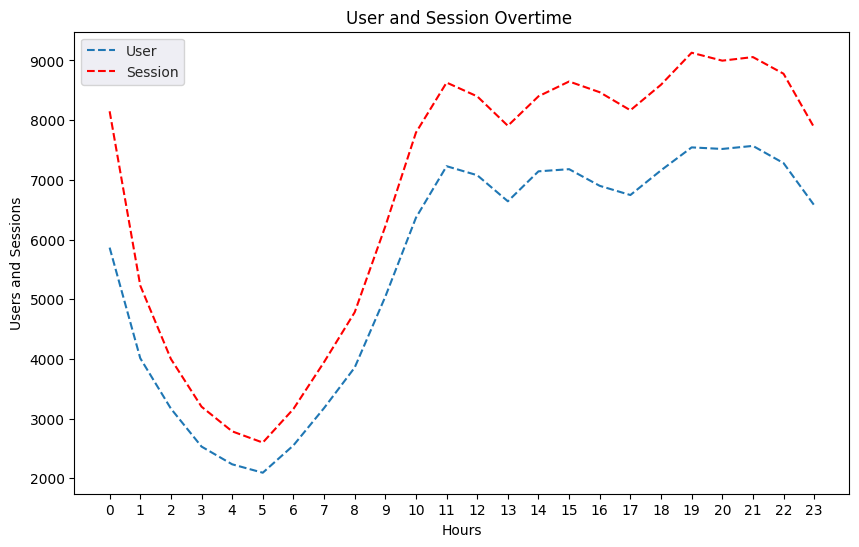

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(x="hours",y="users",data=group,label="User",linestyle='--')
sns.lineplot(x="hours",y="sessions",data=group,label="Session",linestyle='--',color='red')
sns.set_style('darkgrid')
sns.set_palette("bright")
plt.xlabel("Hours")
plt.ylabel("Users and Sessions")
plt.title("User and Session Overtime ")
plt.legend()
plt.xticks(range(24))
plt.show()

## Inference from Users vs Sessions by Hour Analysis
1.Users and session have strong positive corelation

2.Early morning hours have low traffic

3.Traffic rapidly increase After 8 am to 11 am

4.Evening hours are the busiest


## Number of user per channel

In [ ]:
df['channel group'].describe()

,channel group
count,3182
unique,7
top,Direct
freq,672


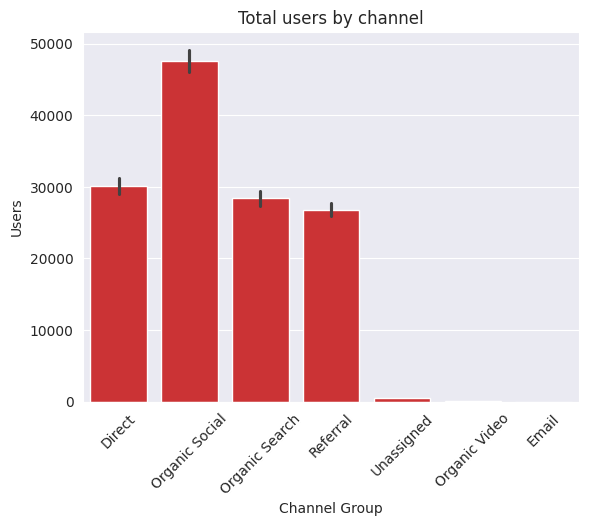

In [ ]:
sns.barplot(x="channel group",y="users",data=df,estimator=np.sum)
sns.set_style('darkgrid')
plt.xlabel("Channel Group")
plt.ylabel("Users")
plt.title("Total users by channel")
plt.xticks(rotation=45)
plt.show()

Organic Search brought the most of users

## Average engagement of user by channnel

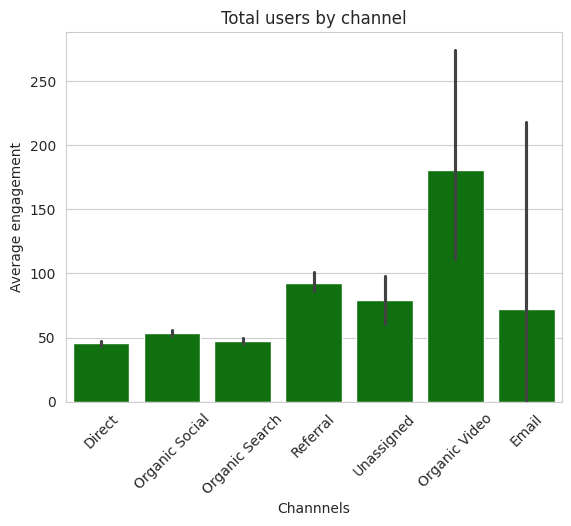

In [ ]:
sns.barplot(x="channel group",y="avg engagement per session",data=df,estimator=np.mean,color="green")
sns.set_style("darkgrid")
sns.set_palette("deep")
plt.xlabel("Channnels")
plt.ylabel("Average engagement")
plt.title("Total users by channel")
plt.xticks(rotation=45)
plt.show()

1. Organic Video channel has the highest engagement of users

2. Email and Referral channel also show hight engagement of users and company should work on it so increase the engagement

## Engagement Rate across different traffic channels

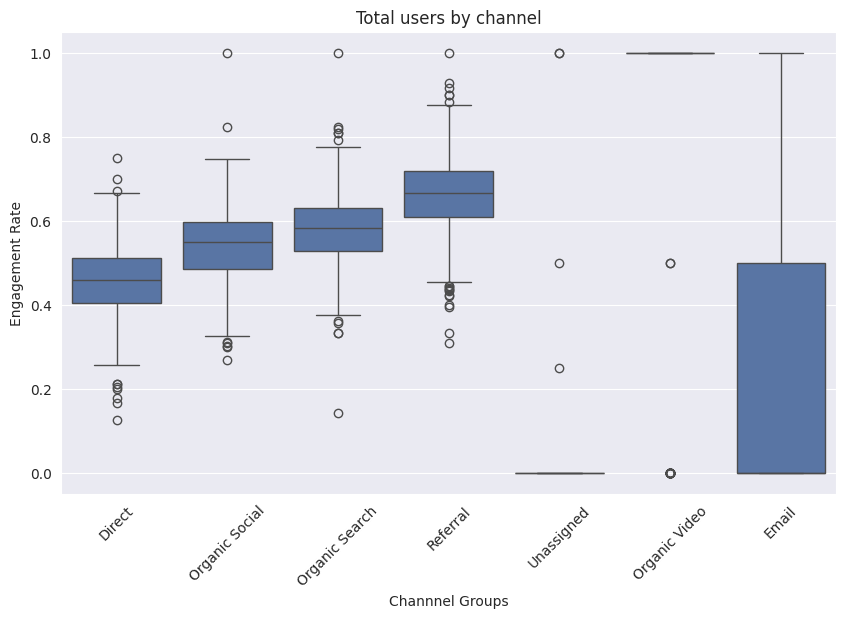

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x="channel group",y="Engagement rate",data=df)
sns.set_style("darkgrid")
sns.set_palette("deep")
plt.xlabel("Channnel Groups")
plt.ylabel("Engagement Rate")
plt.title("Total users by channel")
plt.xticks(rotation=45)
plt.show()

1.Referral traffic generates the most engaged users.

2.organic Search and Organic Social are the next best channels.

3.Direct traffic has average engagement.

## Channel driving more engaged session compared to non-engaged ones

In [ ]:
df.head(1)

,channel group,datetime,users,sessions,engaged sessions,avg engagement per session,engaged session per user,event per session,Engagement rate,Event count,hours
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [ ]:
df_session=df.groupby("channel group")[["sessions","engaged sessions"]].sum().reset_index()
df_session["non engaged sessions"]=df_session["sessions"]-df_session["engaged sessions"]
print(df_session)

    channel group  sessions  engaged sessions  non engaged sessions
0          Direct     37203             17243                 19960
1           Email         3                 1                     2
2  Organic Search     33372             19425                 13947
3  Organic Social     60627             32697                 27930
4   Organic Video       141               109                    32
5        Referral     30990             20653                 10337
6      Unassigned       559                 4                   555


In [ ]:
df_session=df_session.melt(id_vars="channel group",value_vars=["engaged sessions","non engaged sessions"])
df_session.head()

,channel group,variable,value
0,Direct,engaged sessions,17243
1,Email,engaged sessions,1
2,Organic Search,engaged sessions,19425
3,Organic Social,engaged sessions,32697
4,Organic Video,engaged sessions,109


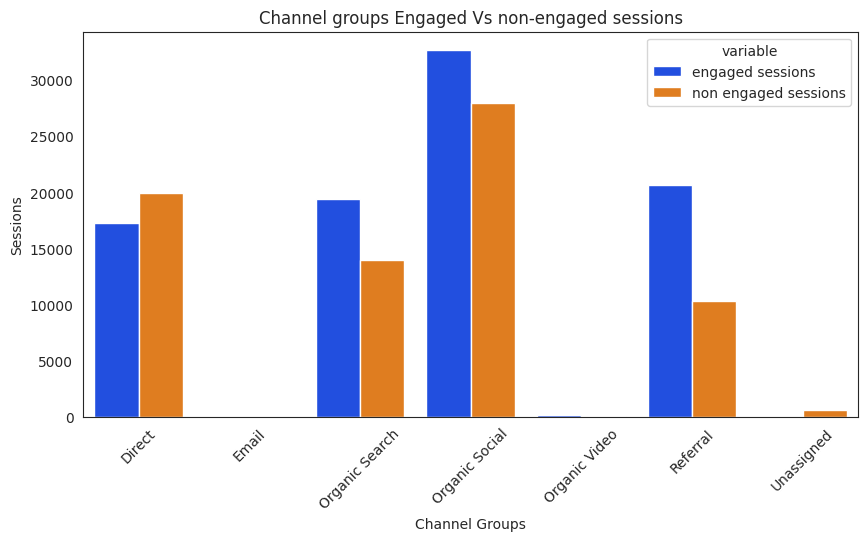

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x="channel group",y="value",hue="variable",data=df_session)
sns.set_style("darkgrid")
sns.set_palette("Set1")
plt.xlabel("Channel Groups")
plt.ylabel("Sessions")
plt.title("Channel groups Engaged Vs non-engaged sessions")
plt.xticks(rotation=45)
plt.show()


1. Direct channel has the more non engaged user compare to engaged users so there is need work on it

2. Also organic social channel has need work on it to improve the engaged users

## Channel traffic by hours

In [ ]:
df.head(1)

,channel group,datetime,users,sessions,engaged sessions,avg engagement per session,engaged session per user,event per session,Engagement rate,Event count,hours
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


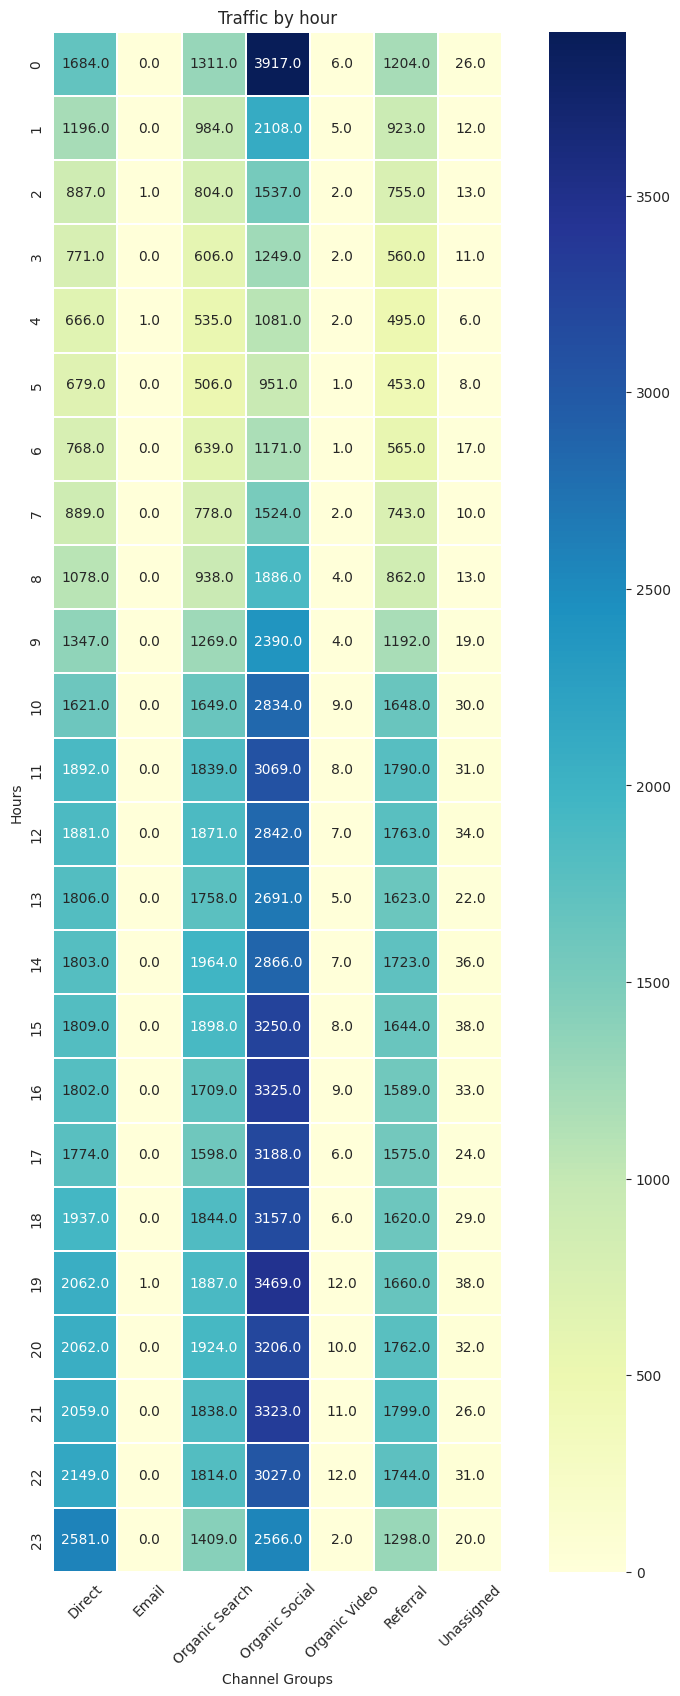

In [ ]:
heat_data=df.groupby(['hours','channel group'])['sessions'].sum().unstack().fillna(0)
plt.figure(figsize=(12,20))
sns.heatmap(heat_data,linewidth=0.1,annot=True,cmap="YlGnBu",fmt='0.1f',square=True)
plt.title("Traffic by hour")
plt.xlabel("Channel Groups")
plt.ylabel("Hours")
plt.xticks(rotation=45)
plt.show()

Inference: The heatmap shows that Organic Social generates the highest website traffic, followed by Direct and Organic Search channels. Traffic is lowest during early morning hours and gradually increases throughout the day, reaching its peak during the evening and late-night hours. Email and Organic Video contribute very little traffic compared to other channels.

## Engagement rate vs over session

In [ ]:
df.head(1)

,channel group,datetime,users,sessions,engaged sessions,avg engagement per session,engaged session per user,event per session,Engagement rate,Event count,hours
0,Direct,2024-04-16 23:00:00,237,300,144,47.526667,0.607595,4.673333,0.48,1402,23


In [ ]:
group=df.groupby("datetime")[["sessions","Engagement rate"]].mean().reset_index()
print(group)

               datetime   sessions  Engagement rate
0   2024-04-06 00:00:00  54.000000         0.450262
1   2024-04-06 01:00:00  35.500000         0.489905
2   2024-04-06 02:00:00  35.500000         0.595759
3   2024-04-06 03:00:00  24.400000         0.446725
4   2024-04-06 04:00:00  25.500000         0.494964
..                  ...        ...              ...
667 2024-05-03 19:00:00  54.000000         0.498125
668 2024-05-03 20:00:00  54.500000         0.375790
669 2024-05-03 21:00:00  74.800000         0.471312
670 2024-05-03 22:00:00  62.333333         0.367749
671 2024-05-03 23:00:00  64.000000         0.585665

[672 rows x 3 columns]


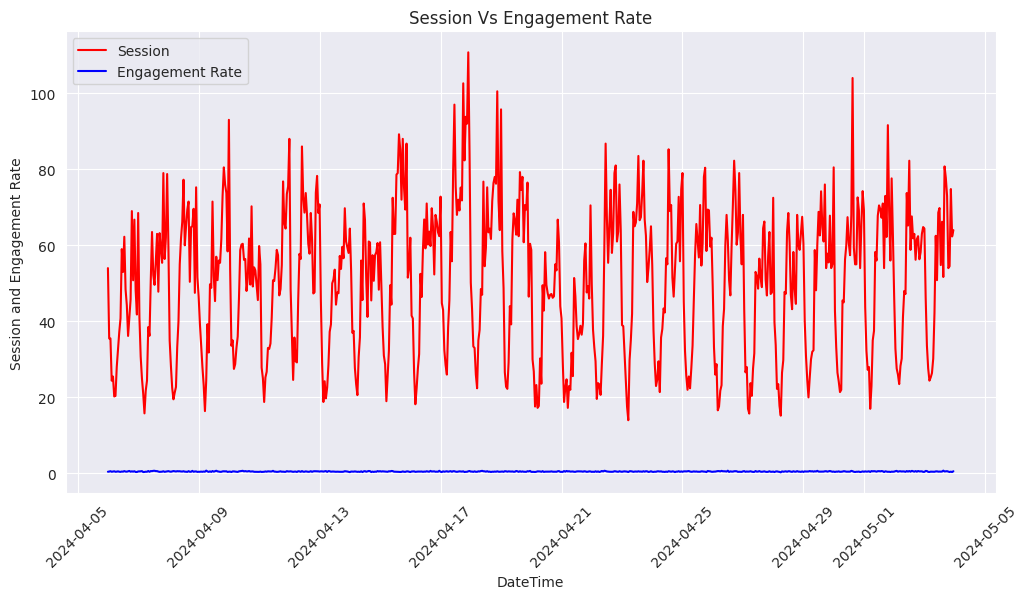

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(x="datetime",y="sessions",data=group,label="Session",color="red")
sns.lineplot(x="datetime",y="Engagement rate",data=group,label="Engagement Rate",color="blue")
plt.xlabel("DateTime")
plt.ylabel("Session and Engagement Rate")
plt.title("Session Vs Engagement Rate")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

Inference: The graph indicates that session counts fluctuate significantly over time, showing several peaks and dips, while the engagement rate remains relatively stable throughout the period. This suggests that although the number of visitors changes daily, the quality of user engagement remains consistent.

# Summary and Key Insights

- Organic Social, Direct, and Organic Search channels were the major contributors to website traffic.
- User engagement remained relatively stable throughout the analysis period despite fluctuations in session counts.
- Traffic distribution showed that a few channels generated the majority of website visits.
- Website activity was highest during evening and late-night hours and lowest during early morning hours.
- Session trends indicated varying user activity patterns across different time periods.
- Email and Organic Video channels contributed comparatively less traffic than other channels.

# Conclusion

The website data analysis provided valuable insights into traffic sources, user engagement, and visitor behavior. The results indicate that Organic Social, Direct, and Organic Search are the primary drivers of website traffic, while engagement levels remain consistently stable. These insights can be used to optimize marketing strategies, content scheduling, and overall website performance.